# Analysing completion time

We use Turing to do a Bayesian analysis of completion time. This is the brother of the notebook called `Simulation Completion Time.ipnyb`

In [1]:
using Revise

In [2]:
using CSV, DataFrames, Statistics, Distributions, Turing, StatsPlots

In [3]:
# Import the models
using ai_codev_study.Models
using ai_codev_study.Commons

[ Info: Precompiling ai_codev_study [1525f3ab-395e-493d-8c62-d85788d417a1] (cache misses: include_dependency fsize change (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [4]:
data = CSV.read("../../data/tasks_merged.csv", DataFrame)

Row,dev1,task1.ai,task1.codehealth,task1.coverage,task1.measured_time,task1.estimated_time,task1.entry_demo_4,task1.entry_demo_5,task1.entry_ai_1,task1.entry_ai_2,task1.entry_ai_3,task1.entry_ai_4,task1.entry_ai_5,task1.entry_ai_6,task1.entry_ai_7,task1.entry_ai_8,task1.entry_ai_9,task1.entry_ai_10,task1.exit_uninterrupted,task1.exit_space_1,task1.exit_space_2,task1.exit_space_3,task1.exit_space_4,task1.exit_space_5,task1.exit_space_6,task1.exit_space_7,task1.exit_space_8,task1.exit_space_9,task1.exit_space_10,task2.dev2,task2.treatment,task2.codehealth,task2.coverage,task2.measured_time,task2.estimated_time,task2.exit_uninterrupted,task2.exit_space_1,task2.exit_space_2,task2.exit_space_3,task2.exit_space_4,task2.exit_space_5,task2.exit_space_6,task2.exit_space_7,task2.exit_space_8,task2.exit_space_9,task2.exit_space_10,task1.ai_xp,task1.ai_pref
,String7,Bool,Float64,Float64,Int64,Float64?,String15,String15,Bool,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,String15?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,String7,String7,Float64,Float64,Float64,Float64?,String15?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Int64,Float64?
1,anon126,true,8.34,0.74,3290,missing,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,Yes,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon136,ai,8.42,0.73,4773.0,missing,Yes,4.0,4.0,1.0,5.0,5.0,4.0,1.0,2.0,3.0,1.0,5,5.0
2,anon126,true,8.34,0.74,3290,missing,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,Yes,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon106,ai,8.07,0.75,15671.0,missing,Yes,5.0,4.0,3.0,1.0,4.0,5.0,5.0,5.0,5.0,2.0,5,5.0
3,anon126,true,8.34,0.74,3290,missing,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,Yes,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon037,ai,8.43,0.73,6327.0,missing,Yes,5.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0,5,5.0
4,anon126,true,8.34,0.74,3290,missing,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,Yes,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon050,ai,8.84,0.9,94967.0,19800.0,No,5.0,5.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,5,5.0
5,anon094,true,8.5,0.71,6601,missing,Professional,Advanced,true,5.0,5.0,5.0,5.0,5.0,4.0,1.0,3.0,4.0,"Yes, but breaks",4.0,4.0,5.0,1.0,5.0,5.0,5.0,4.0,4.0,2.0,anon005,ai,8.64,0.71,391708.0,5400.0,Yes,5.0,3.0,4.0,2.0,4.0,3.0,3.0,4.0,5.0,3.0,5,4.5
6,anon126,true,8.88,0.91,462632,10800.0,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,No,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon136,ai,8.42,0.73,4773.0,missing,Yes,4.0,4.0,1.0,5.0,5.0,4.0,1.0,2.0,3.0,1.0,5,5.0
7,anon126,true,8.88,0.91,462632,10800.0,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,No,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon106,ai,8.07,0.75,15671.0,missing,Yes,5.0,4.0,3.0,1.0,4.0,5.0,5.0,5.0,5.0,2.0,5,5.0
8,anon126,true,8.88,0.91,462632,10800.0,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,No,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon037,ai,8.43,0.73,6327.0,missing,Yes,5.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0,5,5.0
9,anon126,true,8.88,0.91,462632,10800.0,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,No,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon050,ai,8.84,0.9,94967.0,19800.0,No,5.0,5.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,5,5.0


In [5]:
# We'll do a complete case analysis for now, but eventually, we should use some sort of imputation.

In [6]:
selected_columns = ["task1.ai",
                    "task1.ai_xp",
                    "task1.entry_demo_5", 
                    "task1.exit_uninterrupted",
                    "task1.measured_time",
                    "task1.estimated_time",
                    "task2.measured_time", 
                    "task2.estimated_time",
                    "task2.exit_uninterrupted"]

9-element Vector{String}:
 "task1.ai"
 "task1.ai_xp"
 "task1.entry_demo_5"
 "task1.exit_uninterrupted"
 "task1.measured_time"
 "task1.estimated_time"
 "task2.measured_time"
 "task2.estimated_time"
 "task2.exit_uninterrupted"

In [7]:
selected_data = data[!,selected_columns]

Row,task1.ai,task1.ai_xp,task1.entry_demo_5,task1.exit_uninterrupted,task1.measured_time,task1.estimated_time,task2.measured_time,task2.estimated_time,task2.exit_uninterrupted
,Bool,Int64,String15,String15?,Int64,Float64?,Float64,Float64?,String15?
1,true,5,Beginner,Yes,3290,missing,4773.0,missing,Yes
2,true,5,Beginner,Yes,3290,missing,15671.0,missing,Yes
3,true,5,Beginner,Yes,3290,missing,6327.0,missing,Yes
4,true,5,Beginner,Yes,3290,missing,94967.0,19800.0,No
5,true,5,Advanced,"Yes, but breaks",6601,missing,391708.0,5400.0,Yes
6,true,5,Beginner,No,462632,10800.0,4773.0,missing,Yes
7,true,5,Beginner,No,462632,10800.0,15671.0,missing,Yes
8,true,5,Beginner,No,462632,10800.0,6327.0,missing,Yes
9,true,5,Beginner,No,462632,10800.0,94967.0,19800.0,No


There are two different indicators of the time spent. We can aggregate them, but we could also use imputation to merge them in a more elegant way.

For example, try to use a correlation between the `estimated_time` from the `measured_time`, or even use a linear model `measured_time + exit_uninterrupted -> estimated_time` 

In [8]:
function merge_time(time, time_estimated)
    if ismissing(time_estimated)
        return time
    else
        return time_estimated
    end
end

merge_time (generic function with 1 method)

In [9]:
for t in 1:2
    selected_data[!, "task$t.aggregate_time_estimate"] = map(merge_time,
    selected_data[!,"task$t.measured_time"],
    selected_data[!,"task$t.estimated_time"])
end

In [10]:
# dropmissing was too aggressive
# complete_case_data = dropmissing(selected_data)

complete_case_data = dropmissing(selected_data, "task2.exit_uninterrupted")

Row,task1.ai,task1.ai_xp,task1.entry_demo_5,task1.exit_uninterrupted,task1.measured_time,task1.estimated_time,task2.measured_time,task2.estimated_time,task2.exit_uninterrupted,task1.aggregate_time_estimate,task2.aggregate_time_estimate
,Bool,Int64,String15,String15?,Int64,Float64?,Float64,Float64?,String15,Real,Float64
1,true,5,Beginner,Yes,3290,missing,4773.0,missing,Yes,3290,4773.0
2,true,5,Beginner,Yes,3290,missing,15671.0,missing,Yes,3290,15671.0
3,true,5,Beginner,Yes,3290,missing,6327.0,missing,Yes,3290,6327.0
4,true,5,Beginner,Yes,3290,missing,94967.0,19800.0,No,3290,19800.0
5,true,5,Advanced,"Yes, but breaks",6601,missing,391708.0,5400.0,Yes,6601,5400.0
6,true,5,Beginner,No,462632,10800.0,4773.0,missing,Yes,10800.0,4773.0
7,true,5,Beginner,No,462632,10800.0,15671.0,missing,Yes,10800.0,15671.0
8,true,5,Beginner,No,462632,10800.0,6327.0,missing,Yes,10800.0,6327.0
9,true,5,Beginner,No,462632,10800.0,94967.0,19800.0,No,10800.0,19800.0


In [11]:
# We look at modes for the predictors
predictors = ["task2.exit_uninterrupted", "task1.entry_demo_5", "task1.ai_xp"]
for c in predictors
    println(c, ": ", mode(complete_case_data[!,c]))
end

task2.exit_uninterrupted: Yes
task1.entry_demo_5: Advanced
task1.ai_xp: 4


In [12]:
combine(groupby(complete_case_data, predictors),
    "task2.estimated_time" => length)

Row,task2.exit_uninterrupted,task1.entry_demo_5,task1.ai_xp,task2.estimated_time_length
,String15,String15,Int64,Int64
1,Yes,Beginner,3,1
2,Yes,Beginner,4,3
3,Yes,Beginner,5,6
4,Yes,Advanced,1,2
5,Yes,Advanced,2,4
6,Yes,Advanced,3,3
7,Yes,Advanced,4,6
8,Yes,Advanced,5,3
9,Yes,Intermediate,1,4


In [13]:
function prepare_time(seconds::Vector{Float64})
    hours = seconds ./ 3600
    return Commons.center(log.(hours))
end

prepare_time (generic function with 1 method)

In [14]:
# Preparing the predictors
log_time_raw = complete_case_data[!,"task2.measured_time"] |> prepare_time

log_time = complete_case_data[!,"task2.aggregate_time_estimate"] |> prepare_time

ai_use = complete_case_data[!,"task1.ai"] |> 
    v -> convert(Vector{Bool}, v);

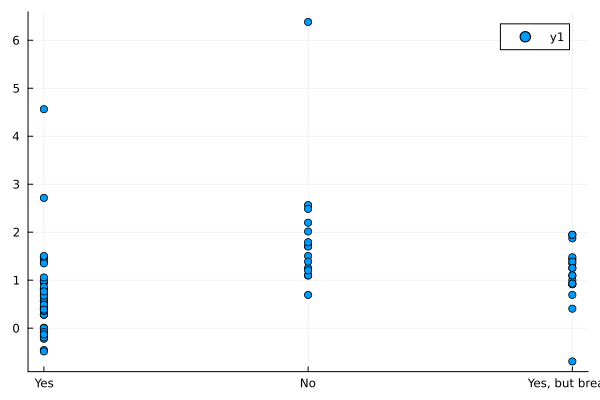

In [15]:
scatter(complete_case_data[!,"task2.exit_uninterrupted"], 
        log.(complete_case_data[!,"task2.aggregate_time_estimate"] ./ 3600))

We see some outliers. We might want to look at that at some point, for example (using a [student distribution](https://en.wikipedia.org/wiki/Student%27s_t-distribution#Robust_parametric_modeling) as a likelihood (or Cauchy, which has DFs of 1). 

# Model 0, Comparing means.

In [16]:
model_0 = Models.completion_time_analysis(ai_use, log_time)

DynamicPPL.Model{typeof(ai_codev_study.Models.completion_time_analysis), (:ai_uses, :log_times), (), (), Tuple{Vector{Bool}, Vector{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.completion_time_analysis, (ai_uses = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], log_times = [-0.737225962262356, 0.4516108702549635, -0.4553748101213684, 0.685480937414374, -0.6138020467158869, -0.737225962262356, 0.4516108702549635, -0.4553748101213684, 0.685480937414374, -0.02334405586480115  …  -1.5035951113579402, 0.9956358657182134, 0.03755816771558407, -0.09082828901424866, 0.33118411588060903, 0.7724923144040037, 0.18487230228120555, 5.360906699026397, 0.23349581367131678, 0.3670272062958393]), NamedTuple(), DynamicPPL.DefaultContext())

In [17]:
chain = sample(model_0, NUTS(), MCMCSerial(), 4000, 4)

┌ Info: Found initial step size
└   ϵ = 0.05
Sampling (Chain 1 of 4): 100%|██████████████████████████| Time: 0:00:00
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (Chain 2 of 4): 100%|██████████████████████████| Time: 0:00:00
┌ Info: Found initial step size
└   ϵ = 0.05
Sampling (Chain 3 of 4): 100%|██████████████████████████| Time: 0:00:00
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (Chain 4 of 4): 100%|██████████████████████████| Time: 0:00:00


Chains MCMC chain (4000×17×4 Array{Float64, 3}):

Iterations        = 1001:1:5000
Number of chains  = 4
Samples per chain = 4000
Wall duration     = 10.21 seconds
Compute duration  = 7.9 seconds
parameters        = intercept, ai_use_effect, sigma
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


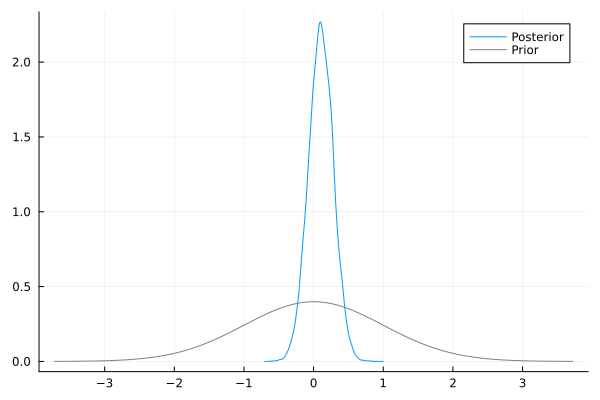

In [18]:
density(chain[:intercept] |> vec, label="Posterior")
plot!(Normal(), color=:grey, label="Prior")

In [19]:
# To plot the effect of a predictor on the percentage scale
function get_pct(x)
    return (exp(x) - 1) * 100
end

function pct_change(samples)
    v = vec(samples)
    pcts = map(get_pct, v)
    return pcts
end

pct_change (generic function with 1 method)

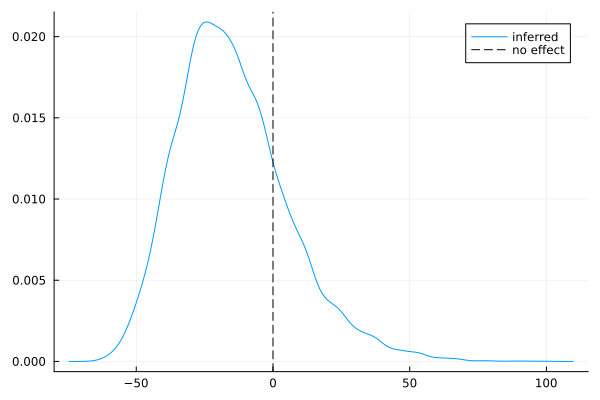

In [20]:
density(pct_change(chain[:ai_use_effect]), label="inferred")
vline!([0.0], color=:black, style=:dash, label="no effect")

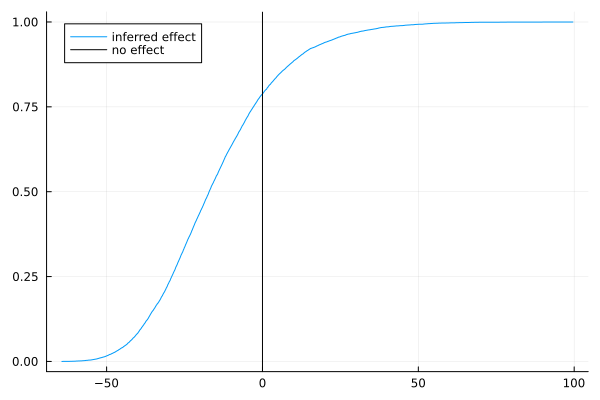

In [21]:
ecdfplot(pct_change(chain[:ai_use_effect]), label="inferred effect")
vline!([0.0], color=:black, label="no effect")

In [22]:
Commons.probability_direction(pct_change(chain[:ai_use_effect]), compare=(<))

0.7881875

About 75% of the distribution is below zero. 

In [23]:
Commons.credibility_interval(pct_change(chain[:ai_use_effect]), 0.95)

2-element Vector{Float64}:
 -47.9
  32.99

We see that AI doesn't have a significant effect here. Between $-40\%$ and $+30\%$

# Looking at interruptions

First, we know that some dev2s have been interrupted...

In [24]:
combine(groupby(complete_case_data, "task2.exit_uninterrupted"), "task2.measured_time" .=> [mean, std])

Row,task2.exit_uninterrupted,task2.measured_time_mean,task2.measured_time_std
,String15,Float64,Float64
1,Yes,44188.7,1.18944e5
2,No,6.06912e5,8.05949e5
3,"Yes, but breaks",1.91851e5,5.536e5


We see a big variation between the three groups. Now, could it be that devs who used AI were having more or less interruptions? 

## Patterns in interruptions? 

I look briefly to see if there seems to be an influence of AI_xp or dev experience on the whether they paused their work or not. 

In [25]:
using GLM

In [26]:
for task in 1:2
    complete_case_data[!,"task$task.interrupted"] = map(u -> u ∈ ["No", "Yes, but breaks"],
        complete_case_data[!,"task$task.exit_uninterrupted"]);
end

In [27]:
# Formula for the regression
f = term("task2.interrupted") ~ term("task1.ai") + term("task1.ai_xp") + term("task1.entry_demo_5")

FormulaTerm
Response:
  task2.interrupted(unknown)
Predictors:
  task1.ai(unknown)
  task1.ai_xp(unknown)
  task1.entry_demo_5(unknown)

In [28]:
glm(f, complete_case_data,
    Bernoulli(), LogitLink(),
    contrasts = Dict(Symbol("task1.entry_demo_5") => DummyCoding(base="Beginner")))

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Bernoulli{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

task2.interrupted ~ 1 + task1.ai + task1.ai_xp + task1.entry_demo_5

Coefficients:
──────────────────────────────────────────────────────────────────────────────────────────────
                                      Coef.  Std. Error      z  Pr(>|z|)  Lower 95%  Upper 95%
──────────────────────────────────────────────────────────────────────────────────────────────
(Intercept)                       -0.113151    0.91074   -0.12    0.9011  -1.89817    1.67187
task1.ai                           0.497625    0.914248   0.54    0.5862  -1.29427    2.28952
task1.ai_xp                       -0.250155    0.299682  -0.83    0.4039  -0.837522   0.337212
task1.entry_demo_5: Advanced       0.74334     0.70697    1.05    0.2931  -0.642297   2.12898
task1.entry_demo_5:

There doesn't seem to be an influence. Back to the regression.

In [29]:
using LinearAlgebra

In [30]:
interruptions_data = let 
    columns = ["task1.ai", "task2.exit_uninterrupted", "task2.aggregate_time_estimate"]
    dropmissing(complete_case_data[!, columns])
end

Row,task1.ai,task2.exit_uninterrupted,task2.aggregate_time_estimate
,Bool,String15,Float64
1,true,Yes,4773.0
2,true,Yes,15671.0
3,true,Yes,6327.0
4,true,No,19800.0
5,true,Yes,5400.0
6,true,Yes,4773.0
7,true,Yes,15671.0
8,true,Yes,6327.0
9,true,No,19800.0


In [31]:
dev2_uninterrupted = indexin(interruptions_data[!,"task2.exit_uninterrupted"],
    ["Yes", "Yes, but breaks", "No"]);

In [32]:
model_1 = Models.completion_time_with_interruptions(
    interruptions_data[!,"task1.ai"],
    dev2_uninterrupted,
    prepare_time(interruptions_data[!,"task2.aggregate_time_estimate"])
)

DynamicPPL.Model{typeof(ai_codev_study.Models.completion_time_with_interruptions), (:ai_use, :dev2_uninterrupted, :log_time), (), (), Tuple{Vector{Bool}, Vector{Union{Nothing, Int64}}, Vector{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.completion_time_with_interruptions, (ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dev2_uninterrupted = Union{Nothing, Int64}[1, 1, 1, 3, 1, 1, 1, 1, 3, 2  …  1, 3, 1, 2, 1, 3, 3, 3, 2, 3], log_time = [-0.737225962262356, 0.4516108702549635, -0.4553748101213684, 0.685480937414374, -0.6138020467158869, -0.737225962262356, 0.4516108702549635, -0.4553748101213684, 0.685480937414374, -0.02334405586480115  …  -1.5035951113579402, 0.9956358657182134, 0.03755816771558407, -0.09082828901424866, 0.33118411588060903, 0.7724923144040037, 0.18487230228120555, 5.360906699026397, 0.23349581367131678, 0.3670272062958393]), NamedTuple(), DynamicPPL.DefaultContext())

In [33]:
chain_1 = sample(model_1, NUTS(), MCMCSerial(), 4000, 4)

┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (Chain 1 of 4): 100%|██████████████████████████| Time: 0:00:01
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (Chain 2 of 4): 100%|██████████████████████████| Time: 0:00:01
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (Chain 3 of 4): 100%|██████████████████████████| Time: 0:00:01
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (Chain 4 of 4): 100%|██████████████████████████| Time: 0:00:01


Chains MCMC chain (4000×22×4 Array{Float64, 3}):

Iterations        = 1001:1:5000
Number of chains  = 4
Samples per chain = 4000
Wall duration     = 13.0 seconds
Compute duration  = 11.81 seconds
parameters        = intercept, ai_use_effect, interruption_effect[1], interruption_effect[2], interruption_effect[3], noise[1], noise[2], noise[3]
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


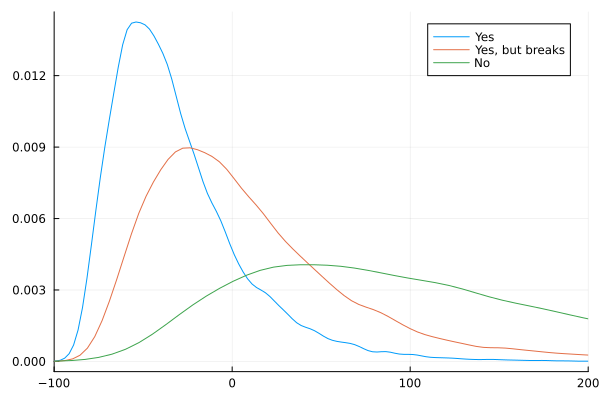

In [34]:
density(pct_change(chain_1["interruption_effect[1]"]) , label="Yes", xrange=(-100, 200))
density!(pct_change(chain_1["interruption_effect[2]"]), label="Yes, but breaks")
density!(pct_change(chain_1["interruption_effect[3]"]), label="No")

We can see a massive difference between the three groups

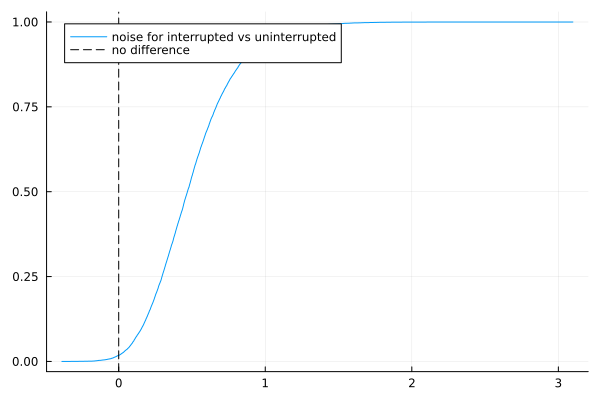

In [35]:
ecdfplot(chain_1["noise[3]"] .- chain_1["noise[1]"] |> vec, 
    label="noise for interrupted vs uninterrupted")
vline!([0.0], color=:black, style=:dash, 
    label="no difference")

In the case of noise, we see more variation (+0.5 std dev) in residuals, for the group of people who were interrupted that those who weren't.

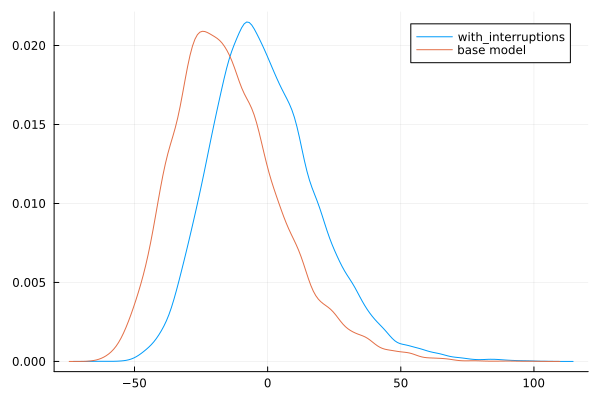

In [36]:
density(pct_change(chain_1[:ai_use_effect]), label="with_interruptions")
density!(pct_change(chain[:ai_use_effect]), label="base model")

When we consider interruptions, we see the effect of AI disappear. But we're just comparing the means, we haven't considered controls.

# Adding Controls

Now, we add more predictors, we use the estimates of time spent from the developers.

In [37]:
ai_xp = complete_case_data[!,"task1.ai_xp"];
dev1_skill = Commons.dev1_skill_to_indexes(complete_case_data[!,"task1.entry_demo_5"]);

In [38]:
# We control for some other factors
model_2 = Models.completion_time_analysis_with_controls_2(ai_use,
    ai_xp, dev1_skill, log_time)

DynamicPPL.Model{typeof(ai_codev_study.Models.completion_time_analysis_with_controls_2), (:ai_use, :ai_xp, :dev1_skill, :log_time, :prior_effect_ai), (), (), Tuple{Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Vector{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.completion_time_analysis_with_controls_2, (ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 2, 1, 1, 3, 1, 1, 1], dev1_skill = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 2, 3, 3, 2, 3, 2, 3, 3, 3], log_time = [-0.737225962262356, 0.4516108702549635, -0.4553748101213684, 0.685480937414374, -0.6138020467158869, -0.737225962262356, 0.4516108702549635, -0.4553748101213684, 0.685480937414374, -0.02334405586480115  …  -1.5035951113579402, 0.9956358657182134, 0.03755816771558407, -0.09082828901424866, 0.33118411588060903, 0.7724923144040037, 0.18487230228120555, 5.360906699026397, 0.23349

In [39]:
chain_2 = sample(model_2, NUTS(), MCMCSerial(), 4000, 4)

┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (Chain 1 of 4): 100%|██████████████████████████| Time: 0:00:01
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (Chain 2 of 4): 100%|██████████████████████████| Time: 0:00:01
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (Chain 3 of 4): 100%|██████████████████████████| Time: 0:00:01
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (Chain 4 of 4): 100%|██████████████████████████| Time: 0:00:01


Chains MCMC chain (4000×26×4 Array{Float64, 3}):

Iterations        = 1001:1:5000
Number of chains  = 4
Samples per chain = 4000
Wall duration     = 15.79 seconds
Compute duration  = 14.45 seconds
parameters        = intercept, effect_ai, ladder_ai_xp[1], ladder_ai_xp[2], ladder_ai_xp[3], ladder_ai_xp[4], ladder_ai_xp[5], effect_skill, ladder_skill[1], ladder_skill[2], ladder_skill[3], sigma
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


In [40]:
ess_rhat(chain_2)

ESS/R-hat
       parameters          ess      rhat   ess_per_sec 
           Symbol      Float64   Float64       Float64 

        intercept    8864.8609    1.0001      613.5701
        effect_ai   17591.0633    1.0002     1217.5431
  ladder_ai_xp[1]   19236.2078    1.0003     1331.4097
  ladder_ai_xp[2]   18307.2578    1.0004     1267.1136
  ladder_ai_xp[3]   19316.9993    1.0000     1337.0016
  ladder_ai_xp[4]   19672.4213    1.0003     1361.6017
  ladder_ai_xp[5]   19543.8056    1.0008     1352.6997
     effect_skill    9361.6089    1.0003      647.9519
  ladder_skill[1]   17573.7471    1.0001     1216.3446
  ladder_skill[2]   16972.2682    1.0003     1174.7140
  ladder_skill[3]   18031.6834    1.0002     1248.0401
            sigma   21201.0020    1.0002     1467.4005


We can see the ESS looks really high, so that's a sign the model sampled well!

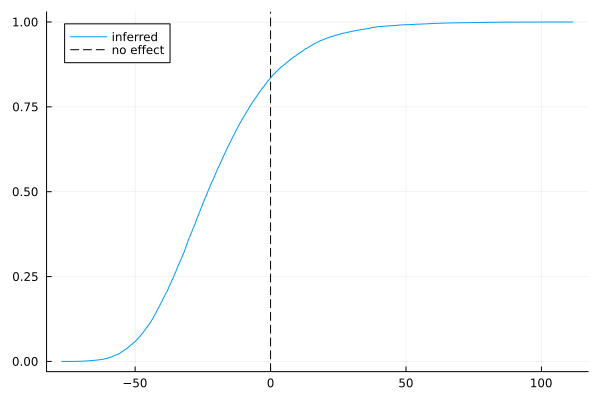

In [41]:
ecdfplot(pct_change(chain_2[:effect_ai]), label="inferred")
vline!([0.0], color=:black, style=:dash, label="no effect")

The effect looks mildly negative, but nothing significant.

In [42]:
Commons.probability_direction(pct_change(chain_2[:effect_ai]), compare=(<))

0.83475

We see we have a 80-85% probability that AI had a positive effect on completion time, though...

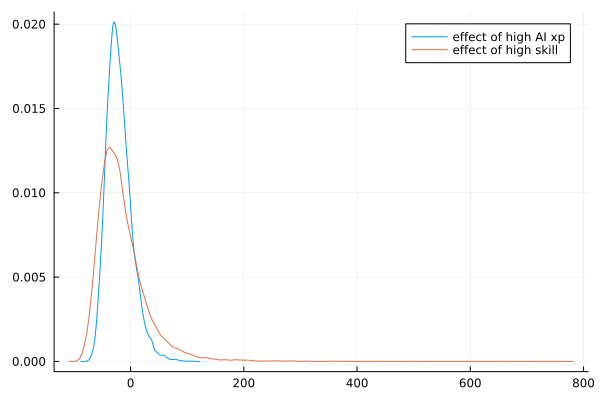

In [81]:
density(pct_change(chain_2[:effect_ai]),
        label="effect of high AI xp")
density!(pct_change(chain_2[:effect_skill]),
         label="effect of high skill")

# Controls and interruptions

In [44]:
dev2_uninterrupted = indexin(complete_case_data[!,"task2.exit_uninterrupted"], 
    ["Yes", "Yes, but breaks", "No"]);

In [45]:
model_3 = Models.completion_time_analysis_with_controls_and_interruptions_2(ai_use,
    ai_xp, dev1_skill, 
    dev2_uninterrupted,
    log_time)

DynamicPPL.Model{typeof(ai_codev_study.Models.completion_time_analysis_with_controls_and_interruptions_2), (:ai_use, :ai_xp, :dev1_skill, :dev2_uninterrupted, :log_time, :prior_effect_ai), (), (), Tuple{Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Vector{Union{Nothing, Int64}}, Vector{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.completion_time_analysis_with_controls_and_interruptions_2, (ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 2, 1, 1, 3, 1, 1, 1], dev1_skill = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 2, 3, 3, 2, 3, 2, 3, 3, 3], dev2_uninterrupted = Union{Nothing, Int64}[1, 1, 1, 3, 1, 1, 1, 1, 3, 2  …  1, 3, 1, 2, 1, 3, 3, 3, 2, 3], log_time = [-0.737225962262356, 0.4516108702549635, -0.4553748101213684, 0.685480937414374, -0.6138020467158869, -0.737225962262356, 0.4516108702549635, -0.4553748101213684, 0.685480937414374, -0

In [46]:
chain_3 = sample(model_3, NUTS(), MCMCThreads(), 4000, 4)

┌ Info: Found initial step size
└   ϵ = 0.05
┌ Info: Found initial step size
└   ϵ = 0.05
┌ Info: Found initial step size
└   ϵ = 0.025
┌ Info: Found initial step size
└   ϵ = 0.025
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:09


Chains MCMC chain (4000×36×4 Array{Float64, 3}):

Iterations        = 1001:1:5000
Number of chains  = 4
Samples per chain = 4000
Wall duration     = 15.07 seconds
Compute duration  = 58.21 seconds
parameters        = intercept, effect_ai, ladder_ai_xp[1], ladder_ai_xp[2], ladder_ai_xp[3], ladder_ai_xp[4], ladder_ai_xp[5], effect_skill, ladder_skill[1], ladder_skill[2], ladder_skill[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, effect_interruptions, ladder_interruptions[1], ladder_interruptions[2], ladder_interruptions[3], residuals[1], residuals[2], residuals[3]
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


In [47]:
describe(chain_3)

Chains MCMC chain (4000×36×4 Array{Float64, 3}):

Iterations        = 1001:1:5000
Number of chains  = 4
Samples per chain = 4000
Wall duration     = 15.07 seconds
Compute duration  = 58.21 seconds
parameters        = intercept, effect_ai, ladder_ai_xp[1], ladder_ai_xp[2], ladder_ai_xp[3], ladder_ai_xp[4], ladder_ai_xp[5], effect_skill, ladder_skill[1], ladder_skill[2], ladder_skill[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, effect_interruptions, ladder_interruptions[1], ladder_interruptions[2], ladder_interruptions[3], residuals[1], residuals[2], residuals[3]
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Summary Statistics
               parameters      mean       std      mcse     ess_bulk     ess_tail      rhat   ess_per_sec 
                   Symbol 

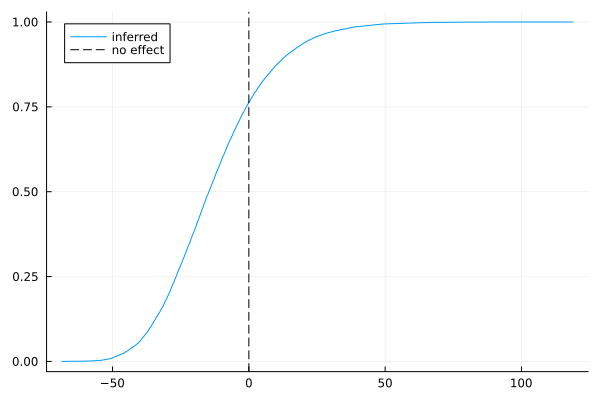

In [48]:
ecdfplot(pct_change(chain_3["effect_ai"]),
    label="inferred")
vline!([0.0], style=:dash, color=:black, 
    label="no effect")

In [83]:
Commons.probability_direction(chain_3["effect_ai"], compare=(<))

0.7626875

About a 75% chance that AI has a positive effect (makes people go faster)

In [88]:
Commons.probability_direction(chain_3["effect_skill_difference"], compare=(<))

0.9276875

A 92% probability that high skill had a positive effect (makes people go faster)

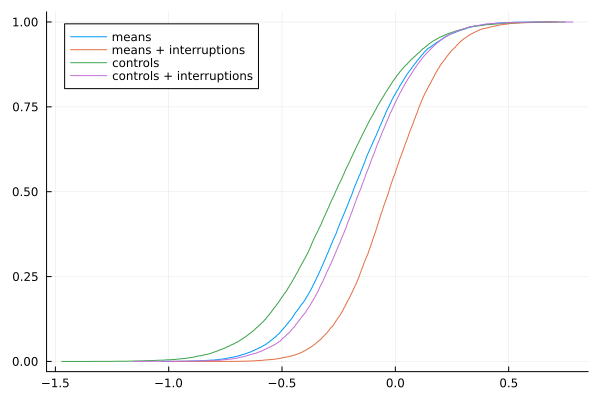

In [51]:
ecdfplot(chain[:ai_use_effect] |> vec, 
    label="means")
ecdfplot!(chain_1[:ai_use_effect] |> vec, 
    label="means + interruptions")
ecdfplot!(chain_2[:effect_ai] |> vec, 
    label="controls")
ecdfplot!(chain_3[:effect_ai] |> vec, 
    label="controls + interruptions")

The posteriors look quite similar. We see that the model when we add interruptions, the effect is less important, but it's more important when we add controls.

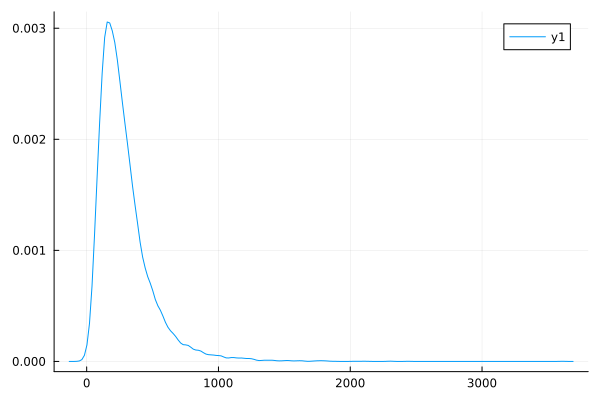

In [52]:
density(pct_change(chain_3[:effect_interruptions]))

Developers which were interrupted took longer *even when they reported their estimates themselves*. By a lot.

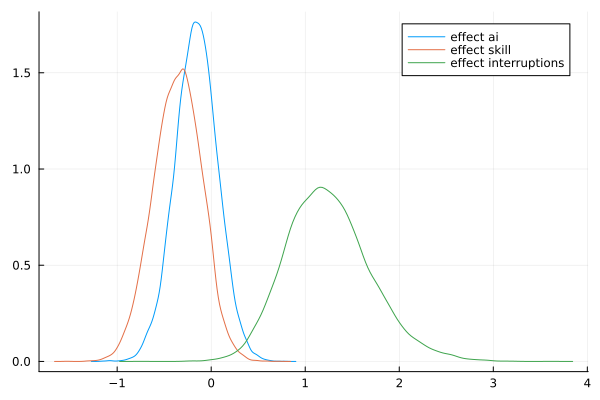

In [89]:
density(chain_3[:effect_ai] |> vec, label="effect ai")
density!(chain_3[:effect_skill_difference] |> vec, label="effect skill")
density!(chain_3[:effect_interruptions] |> vec, label="effect interruptions")

In [90]:
# Effect of using AI when you have High skill, compared with not using AI at all.
pct_effect_ai = pct_change(chain_3[:effect_ai])

Commons.posterior_summary(pct_effect_ai)

(p_delta = 0.76, mean = -12.59, interval_95 = [-45.77, 32.68])

In [94]:
# Effect of using AI, compared with a dev of skill "Beginner".
# Because devs never have "no skill".
pct_effect_skill = pct_change(chain_3[:effect_skill_difference])
Commons.posterior_summary(pct_effect_skill)

(p_delta = 0.93, mean = -27.89, interval_95 = [-57.98, 12.72])

Skill had a more important effect than AI

In [95]:
pct_effect_interruptions = pct_change(chain_3[:effect_interruptions] .* (1 .- chain_3["ladder_interruptions[1]"]))

Commons.posterior_summary(pct_effect_interruptions)

(p_delta = 0.0, mean = 173.66, interval_95 = [37.69, 416.88])

Interruptions caused the most differences, even when people reported their estimated times. Higher skill also decreased the time spent by Dev 2.

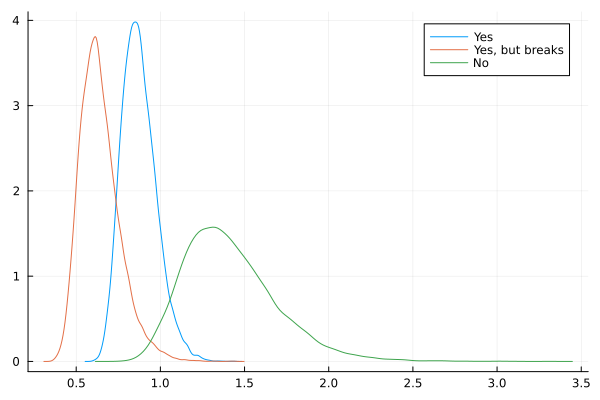

In [96]:
density(vec(chain_3["residuals[1]"]), label="Yes")
density!(vec(chain_3["residuals[2]"]), label="Yes, but breaks")
density!(vec(chain_3["residuals[3]"]), label="No")

# Task 1 vs Task 2

Comparing with task 1.

In [100]:
dev1_uninterrupted = indexin(complete_case_data[!,"task1.exit_uninterrupted"],
        ["Yes", "Yes, but breaks", "No"])
# When we don't know, we say the dev was not "interrupted", just took breaks.
dev1_uninterrupted = map(x -> if isnothing(x) 2 else x end,
    dev1_uninterrupted);

In [101]:
task1_log_time = map(t -> float(t), complete_case_data[!,"task1.aggregate_time_estimate"]) |> prepare_time

76-element Vector{Float64}:
 -1.5064126719253625
 -1.5064126719253625
 -1.5064126719253625
 -1.5064126719253625
 -0.8100790839960095
 -0.31775410257246905
 -0.31775410257246905
 -0.31775410257246905
 -0.31775410257246905
 -0.31775410257246905
 -0.31775410257246905
  1.8308377056144798
 -0.6148631860430088
  ⋮
  0.5985366293016858
  0.6630751504392569
 -0.5205051497668972
  0.3753930779874761
  0.3753930779874761
  0.3753930779874761
 -0.31775410257246905
  0.6630751504392569
  0.25761004233109275
 -0.11753805590196409
 -0.11753805590196409
 -0.11753805590196409

In [102]:
model_31 = Models.completion_time_analysis_with_controls_and_interruptions_2(ai_use,
    ai_xp, dev1_skill, 
    dev1_uninterrupted,
    task1_log_time)

DynamicPPL.Model{typeof(ai_codev_study.Models.completion_time_analysis_with_controls_and_interruptions_2), (:ai_use, :ai_xp, :dev1_skill, :dev2_uninterrupted, :log_time, :prior_effect_ai), (), (), Tuple{Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Vector{Int64}, Vector{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.completion_time_analysis_with_controls_and_interruptions_2, (ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 2, 1, 1, 3, 1, 1, 1], dev1_skill = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 2, 3, 3, 2, 3, 2, 3, 3, 3], dev2_uninterrupted = [1, 1, 1, 1, 2, 3, 3, 3, 3, 2  …  1, 3, 3, 3, 2, 2, 3, 1, 1, 1], log_time = [-1.5064126719253625, -1.5064126719253625, -1.5064126719253625, -1.5064126719253625, -0.8100790839960095, -0.31775410257246905, -0.31775410257246905, -0.31775410257246905, -0.31775410257246905, -0.31775410257246905  …  -0

In [103]:
chain_31 = sample(model_31, NUTS(), MCMCThreads(), 1000, 4)

┌ Info: Found initial step size
└   ϵ = 0.025
┌ Info: Found initial step size
└   ϵ = 0.05
┌ Info: Found initial step size
└   ϵ = 0.0125
┌ Info: Found initial step size
└   ϵ = 0.05
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:03


Chains MCMC chain (1000×36×4 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 4
Samples per chain = 1000
Wall duration     = 3.22 seconds
Compute duration  = 11.49 seconds
parameters        = intercept, effect_ai, ladder_ai_xp[1], ladder_ai_xp[2], ladder_ai_xp[3], ladder_ai_xp[4], ladder_ai_xp[5], effect_skill, ladder_skill[1], ladder_skill[2], ladder_skill[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, effect_interruptions, ladder_interruptions[1], ladder_interruptions[2], ladder_interruptions[3], residuals[1], residuals[2], residuals[3]
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


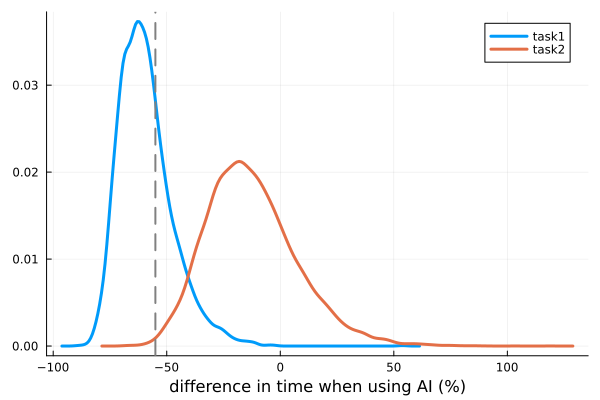

In [104]:
p = density(pct_change(chain_31[:effect_ai]), label="task1",
    xlabel="difference in time when using AI (%)", lw=3)
density!(p, pct_change(chain_3[:effect_ai]), label="task2", lw=3)
# We indicate the result from Peng et al. 
vline!(p, [-55], color=:gray, style=:dash, label=missing, lw=2)

In [105]:
savefig(p, "effect_ai_on_time.pdf")

"/home/noric/Dev/echoes-of-ai-emse-2025/bayesian/notebooks/effect_ai_on_time.pdf"

In [106]:
Commons.posterior_summary(pct_change(chain_31[:effect_ai]))

(p_delta = 1.0, mean = -59.18, interval_95 = [-77.11, -30.64])

In [107]:
Commons.posterior_summary(pct_change(chain_31[:effect_skill_difference]))

(p_delta = 0.83, mean = -21.4, interval_95 = [-60.46, 34.28])

Our results confirm results from previous studies for task 1 (Peng et al. predicted 55% speedup, we see almost the same number). But for task 2, the speedup fades away substantially.

# Sensitivity analysis

We try to the same model (model 3), with 3 different priors for effect of AI.

In [108]:
model_3_optimistic = Models.completion_time_analysis_with_controls_and_interruptions_2(ai_use,
    ai_xp, dev1_skill, 
    dev2_uninterrupted,
    log_time,
    Normal(log(1-0.56), 0.3))

DynamicPPL.Model{typeof(ai_codev_study.Models.completion_time_analysis_with_controls_and_interruptions_2), (:ai_use, :ai_xp, :dev1_skill, :dev2_uninterrupted, :log_time, :prior_effect_ai), (), (), Tuple{Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Vector{Union{Nothing, Int64}}, Vector{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.completion_time_analysis_with_controls_and_interruptions_2, (ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 2, 1, 1, 3, 1, 1, 1], dev1_skill = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 2, 3, 3, 2, 3, 2, 3, 3, 3], dev2_uninterrupted = Union{Nothing, Int64}[1, 1, 1, 3, 1, 1, 1, 1, 3, 2  …  1, 3, 1, 2, 1, 3, 3, 3, 2, 3], log_time = [-0.737225962262356, 0.4516108702549635, -0.4553748101213684, 0.685480937414374, -0.6138020467158869, -0.737225962262356, 0.4516108702549635, -0.4553748101213684, 0.685480937414374, -0

In [109]:
model_3_pessimistic = Models.completion_time_analysis_with_controls_and_interruptions_2(ai_use,
    ai_xp, dev1_skill, 
    dev2_uninterrupted,
    log_time,
    Normal(log(1.56), 0.3))

DynamicPPL.Model{typeof(ai_codev_study.Models.completion_time_analysis_with_controls_and_interruptions_2), (:ai_use, :ai_xp, :dev1_skill, :dev2_uninterrupted, :log_time, :prior_effect_ai), (), (), Tuple{Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Vector{Union{Nothing, Int64}}, Vector{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.completion_time_analysis_with_controls_and_interruptions_2, (ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 2, 1, 1, 3, 1, 1, 1], dev1_skill = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 2, 3, 3, 2, 3, 2, 3, 3, 3], dev2_uninterrupted = Union{Nothing, Int64}[1, 1, 1, 3, 1, 1, 1, 1, 3, 2  …  1, 3, 1, 2, 1, 3, 3, 3, 2, 3], log_time = [-0.737225962262356, 0.4516108702549635, -0.4553748101213684, 0.685480937414374, -0.6138020467158869, -0.737225962262356, 0.4516108702549635, -0.4553748101213684, 0.685480937414374, -0

In [110]:
chain_3_optimistic = sample(model_3_optimistic, NUTS(), MCMCThreads(), 1000, 4)

┌ Info: Found initial step size
└   ϵ = 0.025
┌ Info: Found initial step size
└   ϵ = 0.05
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.0125
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:03


Chains MCMC chain (1000×36×4 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 4
Samples per chain = 1000
Wall duration     = 3.2 seconds
Compute duration  = 12.16 seconds
parameters        = intercept, effect_ai, ladder_ai_xp[1], ladder_ai_xp[2], ladder_ai_xp[3], ladder_ai_xp[4], ladder_ai_xp[5], effect_skill, ladder_skill[1], ladder_skill[2], ladder_skill[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, effect_interruptions, ladder_interruptions[1], ladder_interruptions[2], ladder_interruptions[3], residuals[1], residuals[2], residuals[3]
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


In [111]:
chain_3_pessimistic = sample(model_3_pessimistic, NUTS(), MCMCThreads(),  1000, 4)

┌ Info: Found initial step size
└   ϵ = 0.05
┌ Info: Found initial step size
└   ϵ = 0.0125
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:03


Chains MCMC chain (1000×36×4 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 4
Samples per chain = 1000
Wall duration     = 3.23 seconds
Compute duration  = 11.89 seconds
parameters        = intercept, effect_ai, ladder_ai_xp[1], ladder_ai_xp[2], ladder_ai_xp[3], ladder_ai_xp[4], ladder_ai_xp[5], effect_skill, ladder_skill[1], ladder_skill[2], ladder_skill[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, effect_interruptions, ladder_interruptions[1], ladder_interruptions[2], ladder_interruptions[3], residuals[1], residuals[2], residuals[3]
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


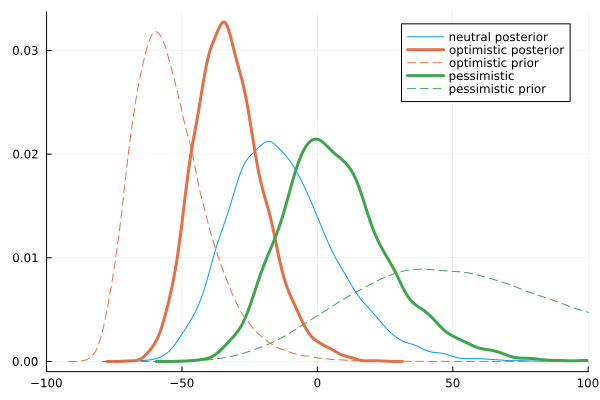

In [112]:
density(pct_change(chain_3[:effect_ai]), label="neutral posterior", xrange=(-100, 100))
density!(pct_change(chain_3_optimistic[:effect_ai]), label="optimistic posterior", lw=3)
density!(pct_change(rand(Normal(log(1-0.56), 0.3), 100000)), label="optimistic prior", color=2, style=:dash)

density!(pct_change(chain_3_pessimistic[:effect_ai]), label="pessimistic", color=3, lw=3)
density!(pct_change(rand(Normal(log(1+0.56), 0.3), 100000)), label="pessimistic prior", color=3, style=:dash)
# density!(, Normal(0.55, 0.3), color=3, label="pessimistic prior", style=:dash)

In [113]:
Commons.probability_direction(pct_change(chain_3_pessimistic[:effect_ai]), compare=(<))

0.3915

In [114]:
Commons.posterior_summary(pct_change(chain_3_optimistic[:effect_ai]))

(p_delta = 0.99, mean = -32.37, interval_95 = [-54.19, -4.5])

In [115]:
Commons.posterior_summary(pct_change(chain_3_pessimistic[:effect_ai]))

(p_delta = 0.39, mean = 7.18, interval_95 = [-26.33, 54.0])

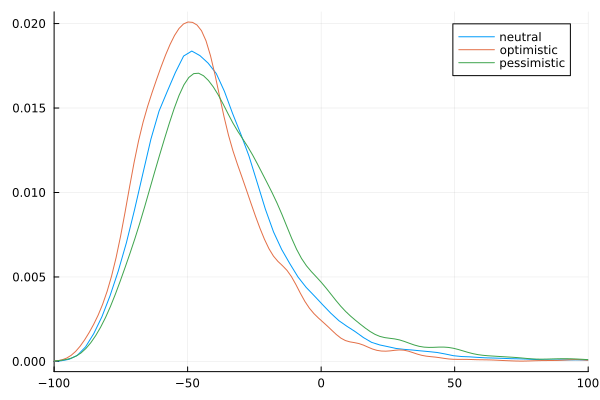

In [116]:
density(pct_change(vec(chain_3[:effect_skill])), label="neutral",
    xrange=(-100, 100))
density!(pct_change(vec(chain_3_optimistic[:effect_skill])), label="optimistic")
# plot!(Normal(-0.55, 0.3), color=2, label="optimistic prior", style=:dash)
density!(pct_change(vec(chain_3_pessimistic[:effect_skill])), label="pessimistic", color=3)

Here, we can see that the use of AI doesn't replace the developer's skill at all. When dev1 was more skilled, dev2 went faster.